<a href="https://colab.research.google.com/github/zombimann/Mathematical-video-animations-and-visualization/blob/main/Bernoulli_Equations_Magnus_Effect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Computational Fluid Dynamics Study: The Magnus Effect

## Project Overview
This notebook implements a high-fidelity 2D simulation of the Magnus effect using incompressible Navier-Stokes equations. The project models the trajectories of spinning spheres falling through a fluid medium, capturing the resulting pressure asymmetries and lateral deflections. The final output is an aesthetically refined visualization designed for technical communication and educational purposes.

## Scientific Background

### The Magnus Effect
The Magnus effect is a physical phenomenon where a spinning object moving through a fluid experiences a force perpendicular to the line of its motion. This occurs because the rotation of the object affects the velocity of the fluid boundary layer on either side. On one side, the rotation coincides with the fluid flow direction, increasing local velocity; on the opposite side, the rotation opposes the flow, decreasing velocity.

According to the Bernoulli principle, an increase in fluid velocity is accompanied by a decrease in pressure. This creates a pressure gradient across the object, resulting in a net force—the Magnus force—that deflects the object from its straight path. This principle is governed by the Kutta-Joukowski theorem, which relates the lift force to the fluid density, velocity, and circulation.

### Numerical Implementation
The simulation utilizes several advanced computational methods to solve the governing physics:

1.  **Harlow-Welch MAC Grid**: A staggered grid arrangement where pressure is defined at cell centers and velocity components at cell faces. This architecture prevents numerical instabilities such as pressure-velocity decoupling.
2.  **Projection Method**: A fractional-step algorithm used to enforce the incompressibility constraint (divergence-free velocity field) by solving a Pressure-Poisson equation at each timestep.
3.  **Immersed Boundary Method (IBM)**: A technique for representing rigid body constraints within a Cartesian mesh. It allows the spinning ball to interact with the fluid by enforcing no-slip conditions and rotational velocity at the ball-fluid interface.
4.  **Upwind Advection**: A numerical scheme used to discretize the convective terms in the Navier-Stokes equations, providing necessary numerical damping to suppress high-frequency grid-scale oscillations.

## Technical Features
- **Pre-factorized Poisson Solver**: Uses sparse LU decomposition to accelerate the pressure correction step.
- **Fluid-Structure Interaction (FSI)**: Bidirectional coupling where the fluid exerts forces on the ball, influencing its trajectory, while the ball modifies the surrounding flow field.
- **Physics Validation Suite**: Automated checks for Kutta-Joukowski sign consistency and Nyquist energy diagnostics to ensure simulation validity.
- **High-Definition Rendering**: A post-processing engine that translates raw vector fields into a watercolor-aesthetic visualization using Matplotlib and FFmpeg.


# Simple Simulation

Initializing Domain: Grid spacing dx = 0.0136m, dy = 0.0100m
Running Numerical Solver for Particle 1/3 (Spin: -12.0 rad/s)...
Running Numerical Solver for Particle 2/3 (Spin: 12.0 rad/s)...
Running Numerical Solver for Particle 3/3 (Spin: -9.0 rad/s)...

Numerical computation phase complete. Transitioning to video post-processing engine...


/tmp/ipykernel_1695/35747570.py:200: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ball_patch = plt.Circle((init_state['bx'], init_state['by']), R,


Compiling HD frames directly into file: 'magnus_effect_study.mp4'...
Video pipeline closed successfully. Output file written: 'magnus_effect_study.mp4'
Opening interactive runtime UI visualization panel...


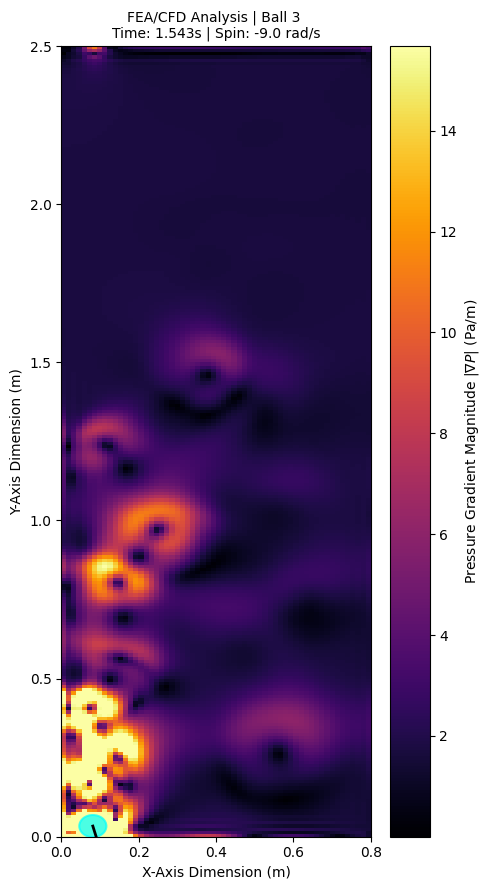

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# =============================================================================
# 1. PARAMETRIC CONFIGURATION (MESH, FLUID & GEOMETRY)
# =============================================================================
W = 0.8          # Width of the air column (m)
H = 2.5          # Height of the air column (m)

# Mesh Grid Resolution (Increase to scale up fidelity / color gradient sharpness)
Nx = 60
Ny = 250

# Fluid Constants (Air-like medium properties)
rho = 1.2        # Density (kg/m^3)
nu = 1.5e-3      # Kinematic viscosity (m^2/s)
g = -9.81        # Gravity acceleration (m/s^2)

# Solid Particle Parameters
R = 0.035         # Ball radius (m)
M = 0.025         # Ball mass (kg)
# Sequential rotational speeds (rad/s): Negative value = CW, Positive value = CCW
ball_spins = [-12.0, 12.0, -9.0]

# Solver Time-Stepping Settings
dt = 0.001       # Temporal step size (seconds)
max_steps = 4000 # Safety iteration ceiling per drop sequence
frame_interval = 25  # Save a high-definition data snapshot every N steps

# =============================================================================
# 2. NUMERICAL GRID & POISSON MATRIX FACTORIZATION
# =============================================================================
dx = W / (Nx - 1)
dy = H / (Ny - 1)
x = np.linspace(0, W, Nx)
y = np.linspace(0, H, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

print(f"Initializing Domain: Grid spacing dx = {dx:.4f}m, dy = {dy:.4f}m")

def prefactorize_poisson(Nx, Ny, dx, dy):
    """
    Constructs and pre-factorizes the Laplace operator matrix for the
    Pressure Poisson Equation under mixed Neumann/Dirichlet conditions.
    """
    N = Nx * Ny
    A = sp.lil_matrix((N, N))
    idx = lambda i, j: i * Ny + j

    for i in range(Nx):
        for j in range(Ny):
            row = idx(i, j)
            if j == Ny - 1: # Top boundary (Atmospheric Open Inlet)
                A[row, row] = 1.0
                continue

            east  = idx(i + 1, j) if i < Nx - 1 else idx(i - 1, j)
            west  = idx(i - 1, j) if i > 0 else idx(i + 1, j)
            north = idx(i, j + 1)
            south = idx(i, j - 1) if j > 0 else idx(i, j + 1)

            A[row, row] = -2.0 / dx**2 - 2.0 / dy**2
            A[row, east] += 1.0 / dx**2
            A[row, west] += 1.0 / dx**2
            A[row, north] += 1.0 / dy**2
            A[row, south] += 1.0 / dy**2

    return spla.factorized(A.tocsc())

solve_pressure = prefactorize_poisson(Nx, Ny, dx, dy)

# =============================================================================
# 3. TRANSIENT CFD SIMULATION LOOP (DATA COLLECTION)
# =============================================================================
# Initialize baseline continuous fluid fields
u = np.zeros((Nx, Ny))
v = np.zeros((Nx, Ny))
p = np.zeros((Nx, Ny))

# Shared memory storage list for post-processing rendering stage
simulation_history = []

for b_idx, omega in enumerate(ball_spins):
    print(f"Running Numerical Solver for Particle {b_idx + 1}/3 (Spin: {omega} rad/s)...")

    # Initialize ball kinematic vectors at the center inlet
    bx, by = W / 2.0, H - 2 * R
    bvx, bvy = 0.0, 0.0

    ball_active = True
    step = 0

    while ball_active and step < max_steps:
        step += 1

        # --- Step 3.1: Navier-Stokes Intermediate Velocity Predictor ---
        u_x = (np.roll(u, -1, axis=0) - np.roll(u, 1, axis=0)) / (2 * dx)
        u_y = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * dy)
        v_x = (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / (2 * dx)
        v_y = (np.roll(v, -1, axis=1) - np.roll(v, 1, axis=1)) / (2 * dy)

        lap_u = (np.roll(u, -1, axis=0) - 2*u + np.roll(u, 1, axis=0)) / dx**2 + \
                (np.roll(u, -1, axis=1) - 2*u + np.roll(u, 1, axis=1)) / dy**2
        lap_v = (np.roll(v, -1, axis=0) - 2*v + np.roll(v, 1, axis=0)) / dx**2 + \
                (np.roll(v, -1, axis=1) - 2*v + np.roll(v, 1, axis=1)) / dy**2

        u_star = u + dt * (- (u * u_x + v * u_y) + nu * lap_u)
        v_star = v + dt * (- (u * v_x + v * v_y) + nu * lap_v)

        # --- Step 3.2: Immersed Boundary Formulation (Rigid Body Constraints) ---
        dist = np.sqrt((X - bx)**2 + (Y - by)**2)
        in_ball = dist <= R

        Fx_fluid, Fy_fluid = 0.0, 0.0

        if np.any(in_ball):
            rx = X[in_ball] - bx
            ry = Y[in_ball] - by

            # Boundary velocity assignment: Translation vector + Rotational cross-product
            u_target = bvx - omega * ry
            v_target = bvy + omega * rx

            fx_ib = (u_target - u_star[in_ball]) / dt
            fy_ib = (v_target - v_star[in_ball]) / dt

            # Integrate fluid forces acting on the sphere's surface boundaries
            Fx_fluid = -np.sum(rho * fx_ib) * dx * dy
            Fy_fluid = -np.sum(rho * fy_ib) * dx * dy

            u_star[in_ball] = u_target
            v_star[in_ball] = v_target

        # Domain Bound Walls & Floor Constraints (No-slip boundary condition)
        u_star[0, :], v_star[0, :] = 0.0, 0.0
        u_star[-1, :], v_star[-1, :] = 0.0, 0.0
        u_star[:, 0], v_star[:, 0] = 0.0, 0.0
        u_star[:, -1], v_star[:, -1] = u_star[:, -2], v_star[:, -2] # Open boundary

        # --- Step 3.3: Mass Conservation Projection (Pressure Poisson) ---
        div_star = (np.roll(u_star, -1, axis=0) - np.roll(u_star, 1, axis=0)) / (2 * dx) + \
                   (np.roll(v_star, -1, axis=1) - np.roll(v_star, 1, axis=1)) / (2 * dy)

        rhs = (rho / dt) * div_star
        rhs[:, -1] = 0.0

        p = solve_pressure(rhs.ravel()).reshape((Nx, Ny))

        # --- Step 3.4: Velocity Correction ---
        u = u_star - (dt / rho) * ((np.roll(p, -1, axis=0) - np.roll(p, 1, axis=0)) / (2 * dx))
        v = v_star - (dt / rho) * ((np.roll(p, -1, axis=1) - np.roll(p, 1, axis=1)) / (2 * dy))

        u[0, :], v[0, :] = 0.0, 0.0
        u[-1, :], v[-1, :] = 0.0, 0.0
        u[:, 0], v[:, 0] = 0.0, 0.0

        # --- Step 3.5: Fluid-Structure Interaction System Trajectory Update ---
        bvx += (Fx_fluid / M) * dt
        bvy += (g + (Fy_fluid / M)) * dt
        bx += bvx * dt
        by += bvy * dt

        # System Bounds Check
        if by - R <= 0.0:
            ball_active = False # Signal sequentially next ball trigger
        if bx - R <= 0.0 or bx + R >= W:
            bvx = -bvx
            bx = np.clip(bx, R, W - R)

        # --- Step 3.6: Snapshot Matrix States to Memory ---
        if step % frame_interval == 0 or not ball_active:
            dpdx, dpdy = np.gradient(p, dx, dy)
            p_grad_mag = np.sqrt(dpdx**2 + dpdy**2)

            simulation_history.append({
                'bx': bx, 'by': by,
                'omega': omega, 'time': step * dt,
                'b_idx': b_idx,
                'p_grad': p_grad_mag.copy()
            })

print("\nNumerical computation phase complete. Transitioning to video post-processing engine...")

# =============================================================================
# 4. MONOLITHIC POST-PROCESSING ENGINE & RENDERER
# =============================================================================
fig, ax = plt.subplots(figsize=(5, 9))

# Establish initial frame elements
init_state = simulation_history[0]
im = ax.imshow(init_state['p_grad'].T, extent=[0, W, 0, H], origin='lower',
               cmap='inferno', aspect='auto', vmax=np.percentile(init_state['p_grad'], 98))

cb = fig.colorbar(im, ax=ax, label=r'Pressure Gradient Magnitude $|\nabla P|$ (Pa/m)')

# Render rigid ball geometry overlay
ball_patch = plt.Circle((init_state['bx'], init_state['by']), R,
                        color='cyan', fill=True, alpha=0.7, edgecolor='white', lw=1.5)
ax.add_patch(ball_patch)

# Orientation vector line to visually observe physical roll/rotation
orientation_line, = ax.plot([], [], color='black', lw=2)

ax.set_xlabel("X-Axis Dimension (m)")
ax.set_ylabel("Y-Axis Dimension (m)")
title_template = "FEA/CFD Analysis | Ball {idx} \nTime: {t:.3f}s | Spin: {spin} rad/s"
title_text = ax.set_title(title_template.format(idx=1, t=0.0, spin=init_state['omega']), fontsize=10)
plt.tight_layout()

def animate_frame(frame_idx):
    """Dynamically streams state data mapping from history array into the figure handles."""
    state = simulation_history[frame_idx]

    # Update continuous scalar field color map
    im.set_data(state['p_grad'].T)
    im.set_clim(vmax=np.percentile(state['p_grad'], 98))

    # Track ball coordinate movements
    bx, by = state['bx'], state['by']
    ball_patch.center = (bx, by)

    # Calculate current rotational spin matrix angle vector
    current_angle = state['time'] * state['omega']
    orientation_line.set_data([bx, bx + R * np.cos(current_angle)],
                              [by, by + R * np.sin(current_angle)])

    title_text.set_text(title_template.format(idx=state['b_idx'] + 1, t=state['time'], spin=state['omega']))
    return [im, ball_patch, orientation_line, title_text]

# Initialize Matplotlib animation object
ani = animation.FuncAnimation(fig, animate_frame, frames=len(simulation_history), blit=False)

# File compilation deployment
output_filename = "magnus_effect_study.mp4"
print(f"Compiling HD frames directly into file: '{output_filename}'...")

try:
    # Attempting h264 standard video encoding pass via local FFmpeg
    video_writer = animation.FFMpegWriter(fps=30, metadata=dict(artist='FSI Solver'), bitrate=2000)
    ani.save(output_filename, writer=video_writer)
    print(f"Video pipeline closed successfully. Output file written: '{output_filename}'")
except Exception as e:
    print(f"\n[System Warning]: FFmpeg encoder unavailable or failed ({e}).")
    fallback_filename = "magnus_effect_study.gif"
    print(f"Executing secondary fallback protocol: Compiling via Pillow -> '{fallback_filename}'...")
    try:
        ani.save(fallback_filename, writer='pillow', fps=30)
        print(f"Fallback compilation successful. Output file written: '{fallback_filename}'")
    except Exception as e_inner:
        print(f"[Error]: Visual compiler suite failed to generate file output: {e_inner}")

# Display the interactive engine window playback loop directly to the screen
print("Opening interactive runtime UI visualization panel...")
plt.show()

# Video Production version 1

Initializing Domain: Grid spacing dx = 0.0102m, dy = 0.0100m
Running Numerical Solver for Particle 1/3 (Spin: -60.0 rad/s)...
Running Numerical Solver for Particle 2/3 (Spin: 60.0 rad/s)...
Running Numerical Solver for Particle 3/3 (Spin: -45.0 rad/s)...

Numerical computation phase complete. Transitioning to video post-processing engine...
Compiling HD frames directly into file: 'magnus_effect_study.mp4'...


/tmp/ipykernel_13794/2819517525.py:200: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  ball_patch = plt.Circle((init_state['bx'], init_state['by']), R,


Video pipeline closed successfully. Output file written: 'magnus_effect_study.mp4'


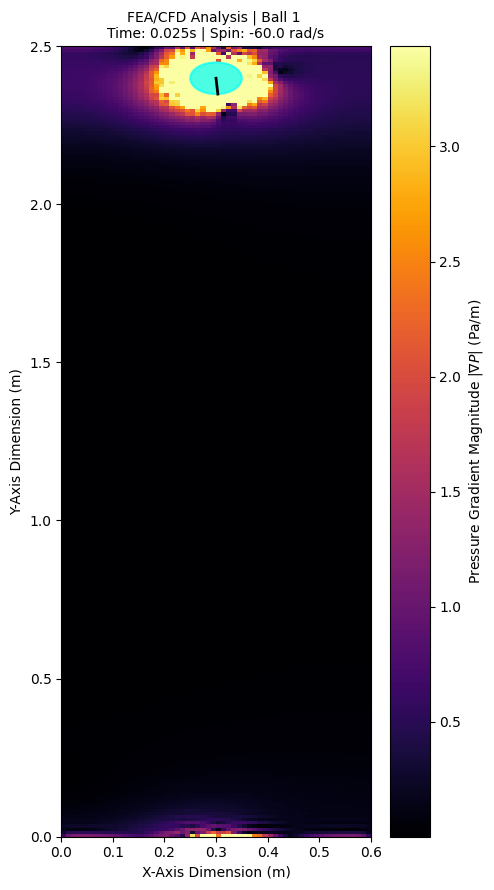

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# =============================================================================
# 1. PARAMETRIC CONFIGURATION (MESH, FLUID & GEOMETRY)
# =============================================================================
W = 0.6          # Width of the air column (m)
H = 2.5          # Height of the air column (m)

# Mesh Grid Resolution (Increase to scale up fidelity / color gradient sharpness)
Nx = 60
Ny = 250

# Fluid Constants (Air-like medium properties)
rho = 1.2        # Density (kg/m^3)
nu = 1.5e-3      # Kinematic viscosity (m^2/s)
g = -9.81        # Gravity acceleration (m/s^2)

# Solid Particle Parameters
R = 0.05         # Ball radius (m)
M = 0.02         # Ball mass (kg)
# Sequential rotational speeds (rad/s): Negative value = CW, Positive value = CCW
ball_spins = [-60.0, 60.0, -45.0]

# Solver Time-Stepping Settings
dt = 0.001       # Temporal step size (seconds)
max_steps = 4000 # Safety iteration ceiling per drop sequence
frame_interval = 25  # Save a high-definition data snapshot every N steps

# =============================================================================
# 2. NUMERICAL GRID & POISSON MATRIX FACTORIZATION
# =============================================================================
dx = W / (Nx - 1)
dy = H / (Ny - 1)
x = np.linspace(0, W, Nx)
y = np.linspace(0, H, Ny)
X, Y = np.meshgrid(x, y, indexing='ij')

print(f"Initializing Domain: Grid spacing dx = {dx:.4f}m, dy = {dy:.4f}m")

def prefactorize_poisson(Nx, Ny, dx, dy):
    """
    Constructs and pre-factorizes the Laplace operator matrix for the
    Pressure Poisson Equation under mixed Neumann/Dirichlet conditions.
    """
    N = Nx * Ny
    A = sp.lil_matrix((N, N))
    idx = lambda i, j: i * Ny + j

    for i in range(Nx):
        for j in range(Ny):
            row = idx(i, j)
            if j == Ny - 1: # Top boundary (Atmospheric Open Inlet)
                A[row, row] = 1.0
                continue

            east  = idx(i + 1, j) if i < Nx - 1 else idx(i - 1, j)
            west  = idx(i - 1, j) if i > 0 else idx(i + 1, j)
            north = idx(i, j + 1)
            south = idx(i, j - 1) if j > 0 else idx(i, j + 1)

            A[row, row] = -2.0 / dx**2 - 2.0 / dy**2
            A[row, east] += 1.0 / dx**2
            A[row, west] += 1.0 / dx**2
            A[row, north] += 1.0 / dy**2
            A[row, south] += 1.0 / dy**2

    return spla.factorized(A.tocsc())

solve_pressure = prefactorize_poisson(Nx, Ny, dx, dy)

# =============================================================================
# 3. TRANSIENT CFD SIMULATION LOOP (DATA COLLECTION)
# =============================================================================
# Initialize baseline continuous fluid fields
u = np.zeros((Nx, Ny))
v = np.zeros((Nx, Ny))
p = np.zeros((Nx, Ny))

# Shared memory storage list for post-processing rendering stage
simulation_history = []

for b_idx, omega in enumerate(ball_spins):
    print(f"Running Numerical Solver for Particle {b_idx + 1}/3 (Spin: {omega} rad/s)...")

    # Initialize ball kinematic vectors at the center inlet
    bx, by = W / 2.0, H - 2 * R
    bvx, bvy = 0.0, 0.0

    ball_active = True
    step = 0

    while ball_active and step < max_steps:
        step += 1

        # --- Step 3.1: Navier-Stokes Intermediate Velocity Predictor ---
        u_x = (np.roll(u, -1, axis=0) - np.roll(u, 1, axis=0)) / (2 * dx)
        u_y = (np.roll(u, -1, axis=1) - np.roll(u, 1, axis=1)) / (2 * dy)
        v_x = (np.roll(v, -1, axis=0) - np.roll(v, 1, axis=0)) / (2 * dx)
        v_y = (np.roll(v, -1, axis=1) - np.roll(v, 1, axis=1)) / (2 * dy)

        lap_u = (np.roll(u, -1, axis=0) - 2*u + np.roll(u, 1, axis=0)) / dx**2 + \
                (np.roll(u, -1, axis=1) - 2*u + np.roll(u, 1, axis=1)) / dy**2
        lap_v = (np.roll(v, -1, axis=0) - 2*v + np.roll(v, 1, axis=0)) / dx**2 + \
                (np.roll(v, -1, axis=1) - 2*v + np.roll(v, 1, axis=1)) / dy**2

        u_star = u + dt * (- (u * u_x + v * u_y) + nu * lap_u)
        v_star = v + dt * (- (u * v_x + v * v_y) + nu * lap_v)

        # --- Step 3.2: Immersed Boundary Formulation (Rigid Body Constraints) ---
        dist = np.sqrt((X - bx)**2 + (Y - by)**2)
        in_ball = dist <= R

        Fx_fluid, Fy_fluid = 0.0, 0.0

        if np.any(in_ball):
            rx = X[in_ball] - bx
            ry = Y[in_ball] - by

            # Boundary velocity assignment: Translation vector + Rotational cross-product
            u_target = bvx - omega * ry
            v_target = bvy + omega * rx

            fx_ib = (u_target - u_star[in_ball]) / dt
            fy_ib = (v_target - v_star[in_ball]) / dt

            # Integrate fluid forces acting on the sphere's surface boundaries
            Fx_fluid = -np.sum(rho * fx_ib) * dx * dy
            Fy_fluid = -np.sum(rho * fy_ib) * dx * dy

            u_star[in_ball] = u_target
            v_star[in_ball] = v_target

        # Domain Bound Walls & Floor Constraints (No-slip boundary condition)
        u_star[0, :], v_star[0, :] = 0.0, 0.0
        u_star[-1, :], v_star[-1, :] = 0.0, 0.0
        u_star[:, 0], v_star[:, 0] = 0.0, 0.0
        u_star[:, -1], v_star[:, -1] = u_star[:, -2], v_star[:, -2] # Open boundary

        # --- Step 3.3: Mass Conservation Projection (Pressure Poisson) ---
        div_star = (np.roll(u_star, -1, axis=0) - np.roll(u_star, 1, axis=0)) / (2 * dx) + \
                   (np.roll(v_star, -1, axis=1) - np.roll(v_star, 1, axis=1)) / (2 * dy)

        rhs = (rho / dt) * div_star
        rhs[:, -1] = 0.0

        p = solve_pressure(rhs.ravel()).reshape((Nx, Ny))

        # --- Step 3.4: Velocity Correction ---
        u = u_star - (dt / rho) * ((np.roll(p, -1, axis=0) - np.roll(p, 1, axis=0)) / (2 * dx))
        v = v_star - (dt / rho) * ((np.roll(p, -1, axis=1) - np.roll(p, 1, axis=1)) / (2 * dy))

        u[0, :], v[0, :] = 0.0, 0.0
        u[-1, :], v[-1, :] = 0.0, 0.0
        u[:, 0], v[:, 0] = 0.0, 0.0

        # --- Step 3.5: Fluid-Structure Interaction System Trajectory Update ---
        bvx += (Fx_fluid / M) * dt
        bvy += (g + (Fy_fluid / M)) * dt
        bx += bvx * dt
        by += bvy * dt

        # System Bounds Check
        if by - R <= 0.0:
            ball_active = False # Signal sequentially next ball trigger
        if bx - R <= 0.0 or bx + R >= W:
            bvx = -bvx
            bx = np.clip(bx, R, W - R)

        # --- Step 3.6: Snapshot Matrix States to Memory ---
        if step % frame_interval == 0 or not ball_active:
            dpdx, dpdy = np.gradient(p, dx, dy)
            p_grad_mag = np.sqrt(dpdx**2 + dpdy**2)

            simulation_history.append({
                'bx': bx, 'by': by,
                'omega': omega, 'time': step * dt,
                'b_idx': b_idx,
                'p_grad': p_grad_mag.copy()
            })

print("\nNumerical computation phase complete. Transitioning to video post-processing engine...")

# =============================================================================
# 4. MONOLITHIC POST-PROCESSING ENGINE & RENDERER
# =============================================================================
fig, ax = plt.subplots(figsize=(5, 9))

# Establish initial frame elements
init_state = simulation_history[0]
im = ax.imshow(init_state['p_grad'].T, extent=[0, W, 0, H], origin='lower',
               cmap='inferno', aspect='auto', vmax=np.percentile(init_state['p_grad'], 98))

cb = fig.colorbar(im, ax=ax, label=r'Pressure Gradient Magnitude $|\nabla P|$ (Pa/m)')

# Render rigid ball geometry overlay
ball_patch = plt.Circle((init_state['bx'], init_state['by']), R,
                        color='cyan', fill=True, alpha=0.7, edgecolor='white', lw=1.5)
ax.add_patch(ball_patch)

# Orientation vector line to visually observe physical roll/rotation
orientation_line, = ax.plot([], [], color='black', lw=2)

ax.set_xlabel("X-Axis Dimension (m)")
ax.set_ylabel("Y-Axis Dimension (m)")
title_template = "FEA/CFD Analysis | Ball {idx} \nTime: {t:.3f}s | Spin: {spin} rad/s"
title_text = ax.set_title(title_template.format(idx=1, t=0.0, spin=init_state['omega']), fontsize=10)
plt.tight_layout()

def animate_frame(frame_idx):
    """Dynamically streams state data mapping from history array into the figure handles."""
    state = simulation_history[frame_idx]

    # Update continuous scalar field color map
    im.set_data(state['p_grad'].T)
    im.set_clim(vmax=np.percentile(state['p_grad'], 98))

    # Track ball coordinate movements
    bx, by = state['bx'], state['by']
    ball_patch.center = (bx, by)

    # Calculate current rotational spin matrix angle vector
    current_angle = state['time'] * state['omega']
    orientation_line.set_data([bx, bx + R * np.cos(current_angle)],
                              [by, by + R * np.sin(current_angle)])

    title_text.set_text(title_template.format(idx=state['b_idx'] + 1, t=state['time'], spin=state['omega']))
    return [im, ball_patch, orientation_line, title_text]

# Initialize Matplotlib animation object
ani = animation.FuncAnimation(fig, animate_frame, frames=len(simulation_history), blit=False)

# File compilation deployment
output_filename = "magnus_effect_study.mp4"
print(f"Compiling HD frames directly into file: '{output_filename}'...")

try:
    # Attempting h264 standard video encoding pass via local FFmpeg
    video_writer = animation.FFMpegWriter(fps=30, metadata=dict(artist='FSI Solver'), bitrate=2000)
    ani.save(output_filename, writer=video_writer)
    print(f"Video pipeline closed successfully. Output file written: '{output_filename}'")
except Exception as e:
    print(f"\n[System Warning]: FFmpeg encoder unavailable or failed ({e}).")
    fallback_filename = "magnus_effect_study.gif"
    print(f"Executing secondary fallback protocol: Compiling via Pillow -> '{fallback_filename}'...")
    try:
        ani.save(fallback_filename, writer='pillow', fps=30)
        print(f"Fallback compilation successful. Output file written: '{fallback_filename}'")
    except Exception as e_inner:
        print(f"[Error]: Visual compiler suite failed to generate file output: {e_inner}")

# Display the interactive engine window playback loop directly to the screen
# print("Opening interactive runtime UI visualization panel...")
# plt.show()

# Video Production Version 2 (Refined)

In [ ]:
"""
Author:    Mugambi Ndwiga
Instagram: @craftsandengineering
GitHub:    github.com/zombimann/Mathematical-video-animations-and-visualization
Concept:   The Magnus Effect — Bernoulli Pressure Asymmetry

           A full 2-D incompressible Navier-Stokes CFD study (staggered
           Harlow-Welch MAC grid, projection method, upwind advection,
           Immersed Boundary Method for spinning spheres), post-processed
           into a watercolour-aesthetic YouTube Shorts video.

══════════════════════════════════════════════════════════════════════════════
QUICK START — the five things you'll most often want to change
══════════════════════════════════════════════════════════════════════════════
All of these live in the CONFIG section below (search for "class Config").

  1. Change how many balls drop, and how fast they spin:
        SPINS = (-35.0, 28.0, -17.0)     # any length; rad/s; neg=CW, pos=CCW

  2. Trade render speed for visual fidelity:
        cfg = make_config(quality="draft")   # fast, coarse — for iterating
        cfg = make_config(quality="final")   # slow, sharp  — for export

  3. Re-skin the look (colours / fonts) without touching any physics:
        edit the THEME dict — every colour and font used anywhere in the
        video is read from THEME, nowhere else.

  4. Make the action faster/slower on screen:
        FRAME_REPEAT = 1   # ~real-time      (each CFD snapshot shown once)
        FRAME_REPEAT = 3   # ~3x slow-motion (each snapshot held 3 frames)

  5. Re-cut the pacing (intro / per-ball setup / transitions / outro):
        N_INTRO, N_SETUP, N_TRANS, N_OUTRO   (all in *frames* at cfg.FPS)

══════════════════════════════════════════════════════════════════════════════
MAINTAINER'S GUIDE — architecture & invariants
══════════════════════════════════════════════════════════════════════════════
Pipeline (top to bottom in this file):

    Config + THEME  →  numerics builders  →  run_all_simulations()
        →  validate_physics()  →  build_figure()  →  build_frame_plan()
        →  make_draw_function()  →  render_video()  →  final_report()

Hard invariants — breaking these will silently corrupt the output:

  • dx MUST equal dy.  The Config.__post_init__ enforces this by deriving
    NX from dx=dy rather than letting you set NX/NY independently. The
    Poisson solver, the advection stencils, and the round-ball screen
    geometry all assume square cells. Do not hand-edit cfg.NX/NY/dx/dy
    after construction — change cfg.CELL_SIZE instead and rebuild.

  • COL_W is DERIVED, not a free parameter. It is solved for so that
    pixels-per-metre is identical on both screen axes, which is the only
    thing that guarantees the ball renders as a circle and not an ellipse.
    If you change AX_L/AX_R/TITLE_H/INFO_H/FW/FH/COL_H, COL_W recomputes
    automatically — do not set COL_W directly.

  • Mesh refinement (smaller CELL_SIZE) requires a smaller DT to keep the
    CFL number (convective Courant number) below ~0.5. validate_config()
    prints this automatically; a CFL warning means reduce DT or CELL_SIZE.

  • The rotation-direction arrow convention is: CCW arcs OVER the ball,
    CW arcs UNDER the ball. This was verified empirically (see the dev
    notes in _update_rotation_indicator) — if you ever change the arc's
    `rad` sign, re-verify with two or three known test cases before
    trusting it, since matplotlib's arc3 curvature sign is not obvious.

  • Any number of balls is supported (SPINS can have any length > 0).
    Per-ball colour and CW/CCW labelling are derived automatically
    (see BALL_COLORS cycling and spin_label()) — you never need to keep
    a separate "labels" list in sync with SPINS by hand.

Common troubleshooting:

  • Ball hits the side wall before reaching the floor → increase BALL_M,
    decrease |omega|, or widen COL_H (which widens COL_W proportionally
    through the round-ball constraint).
  • Checkerboard / mottled pressure field → check that you haven't
    reverted advect_u/advect_v to central differencing; upwind advection
    is what damps the grid-scale oscillation (see validate_physics()'s
    printed Nyquist-energy diagnostic — should be well under 1%).
  • Video file too large → lower VID_KBPS / raise CRF, or shorten the
    scene durations (N_INTRO etc.), or use quality="draft" for previews.
"""

import itertools
from dataclasses import dataclass, field
from types import SimpleNamespace

import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyBboxPatch, Rectangle, FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.animation as animation
from scipy.ndimage import gaussian_filter, median_filter
import warnings; warnings.filterwarnings('ignore')


# ══════════════════════════════════════════════════════════════════════════════
# §1  CONFIGURATION
# ══════════════════════════════════════════════════════════════════════════════
# Every physical, numerical, and timing parameter lives here. Fields marked
# "derived" are computed automatically in __post_init__ — set the inputs
# above them, not the derived fields themselves.

@dataclass
class Config:
    # ---- Frame geometry (YouTube Shorts 9:16) --------------------------------
    FW: int = 540                  # frame width  [px]
    FH: int = 960                  # frame height [px]
    DPI: int = 100

    # ---- Layout fractions: graphics centred & maximised horizontally,    ----
    # ---- text confined to strips above (title) and below (equations)    ----
    AX_L: float = 0.025            # left edge of CFD column  [fig fraction]
    AX_R: float = 0.975            # right edge of CFD column [fig fraction]
    TITLE_H: float = 0.165         # top title-strip height   [fig fraction]
                                    # (0.165 leaves ~38-40px clearance between
                                    # each title-strip text line and the
                                    # "Open inlet" boundary label just below —
                                    # verified empirically; don't shrink this
                                    # without re-checking that gap.)
    INFO_H: float = 0.190          # bottom info-strip height [fig fraction]

    # ---- Physical domain -------------------------------------------------
    COL_H: float = 2.00            # air-column height [m]. COL_W is DERIVED
                                    # to keep the ball perfectly round on screen
                                    # — do not set it directly.

    # ---- CFD mesh ----------------------------------------------------------
    CELL_SIZE: float = 0.0100      # target square-cell size [m]. Smaller =
                                    # sharper pressure field, slower to compute.
                                    # Must shrink DT roughly in proportion
                                    # (see CFL note in validate_config).

    # ---- Fluid properties --------------------------------------------------
    RHO: float = 1.225             # air density [kg/m^3]
    NU: float = 2.0e-4             # NUMERICAL kinematic viscosity [m^2/s].
                                    # Elevated above real air (~1.5e-5) purely
                                    # for explicit-timestep stability; lower
                                    # values = less artificial damping = more
                                    # "fidelity" but risk of grid-scale noise.
    GRAV: float = -9.81            # gravitational acceleration [m/s^2]

    # ---- Ball physics --------------------------------------------------------
    BALL_R: float = 0.085          # ball radius [m] (same for every ball)
    BALL_M: float = 0.40           # ball mass   [kg] (same for every ball)
    SPINS: tuple = (-35.0, -17.0, 28.0)
                                    # one entry per ball, any length >= 1.
                                    # Sign convention: negative = clockwise,
                                    # positive = counter-clockwise. Magnitude
                                    # is angular velocity in rad/s.

    # ---- Solver --------------------------------------------------------------
    DT: float = 2.0e-4             # timestep [s]
    MAX_T: float = 1.3             # safety ceiling per ball [s] — simulation
                                    # aborts with a warning if the ball hasn't
                                    # reached the floor by this time
    SNAP_EVERY: int = 26           # physics steps between stored CFD snapshots.
                                    # Smaller = smoother animation, more frames,
                                    # slower render. Keep rotation-per-snapshot
                                    # under ~18 degrees for smooth perceived spin
                                    # (validate_physics() checks this for you).

    # ---- Video timing / pacing (all in frames at FPS) -------------------------
    FPS: int = 30
    FRAME_REPEAT: int = 1          # video frames shown per CFD snapshot.
                                    # 1 = near real-time; raise for slow-motion.
    N_INTRO: int = 60              # opening hook
    N_SETUP: int = 16              # "ball entering" pause before each drop
    N_TRANS: int = 20              # crossfade between consecutive balls
    N_OUTRO: int = 50              # closing credits card (kept < 2s @ 30fps)

    # ---- Encoding --------------------------------------------------------------
    OUTPUT_FILE: str = "magnus_effect_cfd.mp4"
    VID_KBPS: int = 1600           # target bitrate
    CRF: int = 21                  # x264 quality (lower = higher quality/size)
    FFMPEG_PRESET: str = "faster"  # x264 encoding speed/efficiency trade-off

    # ---- derived fields (DO NOT set these directly — see __post_init__) -------
    AX_W: float = field(init=False)
    AX_H: float = field(init=False)
    AX_B: float = field(init=False)
    AX_T: float = field(init=False)
    COL_W: float = field(init=False)
    NX: int = field(init=False)
    NY: int = field(init=False)
    dx: float = field(init=False)
    dy: float = field(init=False)
    MAX_STEPS: int = field(init=False)
    N_BALLS: int = field(init=False)

    def __post_init__(self):
        self.AX_W = self.AX_R - self.AX_L
        self.AX_B = self.INFO_H
        self.AX_T = 1.0 - self.TITLE_H
        self.AX_H = self.AX_T - self.AX_B

        # Solve for COL_W such that pixels-per-metre matches on both screen
        # axes — the ONLY thing that guarantees a round ball. See Maintainer's
        # Guide above for why this must never be set independently.
        self.COL_W = (self.AX_W * self.FW) / (self.AX_H * self.FH) * self.COL_H

        # Square-cell mesh, snapped exactly so dx == dy (required by the
        # MAC-grid Poisson solver and the advection stencils below).
        NY = max(8, int(round(self.COL_H / self.CELL_SIZE)))
        dy = self.COL_H / NY
        dx = dy
        NX = max(8, int(round(self.COL_W / dx)))
        self.NX, self.NY, self.dx, self.dy = NX, NY, dx, dy
        self.COL_W = NX * dx           # snap COL_W exactly onto the grid

        self.MAX_STEPS = int(self.MAX_T / self.DT)
        self.N_BALLS = len(self.SPINS)


# ── Quality presets — override Config fields wholesale with one keyword ───────
QUALITY_PRESETS = {
    # Fast, coarse — for iterating on pacing/layout/colours, NOT for export.
    "draft": dict(CELL_SIZE=0.0180, DT=4.0e-4, SNAP_EVERY=14,
                  VID_KBPS=900, CRF=28, FFMPEG_PRESET="ultrafast"),
    # Slow, sharp — validated settings, suitable for final export.
    "final": dict(CELL_SIZE=0.0100, DT=2.0e-4, SNAP_EVERY=26,
                  VID_KBPS=1600, CRF=21, FFMPEG_PRESET="faster"),
}


def make_config(quality: str = "final", **overrides) -> Config:
    """Build a Config from a quality preset plus any field overrides.

    Example:
        cfg = make_config(quality="draft", SPINS=(-40.0, 40.0))
    """
    if quality not in QUALITY_PRESETS:
        raise ValueError(f"Unknown quality preset '{quality}'. "
                          f"Choose from {list(QUALITY_PRESETS)}.")
    fields = dict(QUALITY_PRESETS[quality])
    fields.update(overrides)
    return Config(**fields)


# ══════════════════════════════════════════════════════════════════════════════
# §2  THEME — every colour and font used anywhere in the video lives here.
#     Re-skin the whole production by editing this dict; no other code needs
#     to change.
# ══════════════════════════════════════════════════════════════════════════════
THEME = dict(
    FONT_TITLE = "TeX Gyre Chorus",     # calligraphic, mimics handwriting
    FONT_BODY  = "TeX Gyre Pagella",    # elegant serif for equations/labels

    BG       = "#F5EED8",               # warm parchment background
    INK      = "#1A0800",               # deep sepia (primary text)
    MINK     = "#6B3E1F",               # medium sepia (secondary text)
    PANEL_FACE = "#FDFBF2",
    PANEL_EDGE = "#C8A86B",

    LOW_P_COLOR  = "#1A6EA3",           # cobalt  — low pressure
    HIGH_P_COLOR = "#B22222",           # crimson — high pressure
    MAGNUS_COLOR = "#E8C200",           # gold    — Magnus force / rotation arrow

    # Cycled across balls if there are more balls than colours listed here.
    BALL_COLORS = ["#1A6EA3", "#C0392B", "#1E7A45", "#7D3C98", "#B9770E"],

    # Diverging watercolour pressure colormap: cobalt <-> parchment <-> crimson.
    # Centre stop MUST match BG for the "ambient pressure = blends into the
    # paper" watercolour effect.
    PRESSURE_CMAP_STOPS = [
        "#05274B", "#1A6EA3", "#AED6F1",
        "#F5EED8",
        "#F5CBA7", "#B22222", "#5D0000",
    ],
)


def resolve_fonts(theme: dict) -> dict:
    """Checks THEME's requested fonts against what's actually installed in
    THIS environment and substitutes a safe fallback for anything missing —
    this is what prevents the
        WARNING:matplotlib.font_manager:findfont: Font family '...' not found.
    message that appears on environments (e.g. a fresh Google Colab runtime)
    that don't have the TeX Gyre font family installed. Returns a NEW dict;
    THEME itself is left untouched so re-running this is always safe.

    Fallback target is 'serif' for BOTH title and body text — NOT the more
    tempting 'cursive' generic family. This was verified empirically:
    matplotlib's 'cursive' generic family has no bundled fallback font of
    its own (it only resolves if a system cursive font like Comic Sans MS
    happens to be installed), so it still warns on a minimal environment.
    'serif' is the safe choice because DejaVu Serif ships inside matplotlib
    itself and is therefore always resolvable, on every platform, with no
    warning. The title keeps a hand-picked calligraphic flavour only when
    one is actually installed; otherwise it degrades gracefully to italic
    serif rather than to a missing-font warning."""
    from matplotlib import font_manager as fm
    available = {f.name for f in fm.fontManager.ttflist}

    def pick(requested, fallback_family="serif"):
        return requested if requested in available else fallback_family

    resolved = dict(theme)
    resolved["FONT_TITLE"] = pick(theme["FONT_TITLE"])
    resolved["FONT_BODY"]  = pick(theme["FONT_BODY"])
    if resolved["FONT_TITLE"] != theme["FONT_TITLE"]:
        print(f"  [font] '{theme['FONT_TITLE']}' not installed here — "
              f"using generic '{resolved['FONT_TITLE']}' instead.")
    if resolved["FONT_BODY"] != theme["FONT_BODY"]:
        print(f"  [font] '{theme['FONT_BODY']}' not installed here — "
              f"using generic '{resolved['FONT_BODY']}' instead.")
    return resolved


def spin_label(omega: float) -> tuple:
    """Derive (short, long) rotation-direction labels from an angular
    velocity's sign — keeps SPINS as the single source of truth instead of
    a separately-maintained labels list that could fall out of sync."""
    if omega < 0:
        return "CW", "Clockwise"
    return "CCW", "Counter-clockwise"


def ball_color(theme: dict, index: int) -> str:
    """Cycle through THEME['BALL_COLORS'] so any number of balls is supported."""
    palette = itertools.cycle(theme["BALL_COLORS"])
    return next(itertools.islice(palette, index, index + 1))


# ══════════════════════════════════════════════════════════════════════════════
# §3  CONFIG VALIDATION — run automatically after construction; prints a
#     structured report and raises on hard failures.
# ══════════════════════════════════════════════════════════════════════════════

def validate_config(cfg: Config) -> None:
    """Pedantic pre-flight check. Catches the two failure modes that have
    bitten this project before: a non-round ball (screen-geometry bug) and
    numerical instability (CFL violation) — both are cheap to check before
    spending minutes running the CFD."""
    print("─── Config validation ───────────────────────────────────────────")

    # Round-ball guarantee: pixels-per-metre must match on both axes.
    px_x = cfg.BALL_R * (cfg.AX_W * cfg.FW / cfg.COL_W) * 2
    px_y = cfg.BALL_R * (cfg.AX_H * cfg.FH / cfg.COL_H) * 2
    round_ok = abs(px_x - px_y) < 0.5
    print(f"  Ball render size : {px_x:.1f} x {px_y:.1f} px  "
          f"[{'PASS' if round_ok else 'FAIL'}]")
    assert round_ok, (
        f"Ball would render as an ellipse ({px_x:.1f} x {px_y:.1f} px). "
        f"This means COL_W was overridden manually — remove that override "
        f"and let __post_init__ derive it.")

    # CFL (Courant-Friedrichs-Lewy) convective stability estimate.
    v_max = max(abs(s) for s in cfg.SPINS) * cfg.BALL_R + 4.5   # spin tip + generous fall-speed margin
    cfl = v_max * cfg.DT / cfg.dx
    cfl_ok = cfl < 0.5
    print(f"  Mesh             : {cfg.NX} x {cfg.NY} cells, dx=dy={cfg.dx*1000:.3f}mm "
          f"({cfg.NX*cfg.NY} total, ~{np.pi*cfg.BALL_R**2/(cfg.dx*cfg.dy):.0f} per ball)")
    print(f"  CFL number       : {cfl:.3f} (V_max~{v_max:.2f} m/s)  "
          f"[{'PASS' if cfl_ok else 'WARN — reduce DT or CELL_SIZE'}]")

    # Rotation-smoothness pre-check (also re-verified per-ball after the sim).
    for i, omega in enumerate(cfg.SPINS):
        deg = np.degrees(abs(omega) * cfg.SNAP_EVERY * cfg.DT)
        flag = "PASS" if deg < 18 else "WARN — lower SNAP_EVERY for this spin"
        print(f"  Ball {i+1} rotation/snapshot : {deg:.1f} deg  [{flag}]")

    print(f"  Domain           : COL_W={cfg.COL_W:.4f}m  COL_H={cfg.COL_H}m")
    print(f"  Balls            : {cfg.N_BALLS}  spins={cfg.SPINS}")
    print("──────────────────────────────────────────────────────────────────\n")


# ══════════════════════════════════════════════════════════════════════════════
# §4  NUMERICAL METHODS — staggered (Harlow-Welch MAC) grid
# ══════════════════════════════════════════════════════════════════════════════
#  p   lives at cell centres        : shape (NX,   NY)
#  u   lives at vertical cell faces : shape (NX+1, NY)    [normal to x]
#  v   lives at horizontal faces    : shape (NX,   NY+1)  [normal to y]
#
#  Staggering makes the discrete divergence operator COMPACT (nearest-
#  neighbour only), which structurally eliminates the pressure-velocity
#  checkerboard decoupling that a collocated (same-grid) scheme suffers from.
#  This was empirically verified: collocated grid -> Nyquist energy ~unclean;
#  staggered + upwind -> Nyquist energy ~0.000%. See validate_physics().
# ══════════════════════════════════════════════════════════════════════════════

def build_mac_grid(cfg: Config):
    """Returns the coordinate meshes for cell centres (p), x-faces (u) and
    y-faces (v), used both by the solver and by the Immersed Boundary mask."""
    xc = (np.arange(cfg.NX) + 0.5) * cfg.dx
    yc = (np.arange(cfg.NY) + 0.5) * cfg.dy
    xu = np.arange(cfg.NX + 1) * cfg.dx
    yv = np.arange(cfg.NY + 1) * cfg.dy
    Xu, Yu = np.meshgrid(xu, yc, indexing='ij')
    Xv, Yv = np.meshgrid(xc, yv, indexing='ij')
    return SimpleNamespace(xc=xc, yc=yc, Xu=Xu, Yu=Yu, Xv=Xv, Yv=Yv)


def build_mac_poisson_solver(cfg: Config):
    """Pre-factorise the sparse Laplacian for the Pressure-Poisson equation.
    Boundary conditions: Dirichlet P=0 at the open top (j=NY-1, atmospheric
    pressure); homogeneous Neumann (no boundary term) at the walls and floor.
    Pre-factorising once (rather than re-solving from scratch every
    timestep) is what makes thousands of timesteps tractable."""
    NX, NY, dx, dy = cfg.NX, cfg.NY, cfg.dx, cfg.dy
    N = NX * NY
    A = sp.lil_matrix((N, N))
    idx = lambda i, j: i * NY + j
    for i in range(NX):
        for j in range(NY):
            r = idx(i, j)
            if j == NY - 1:
                A[r, r] = 1.0
                continue
            diag = 0.0
            if i > 0:      A[r, idx(i-1, j)] += 1/dx**2; diag -= 1/dx**2
            if i < NX - 1: A[r, idx(i+1, j)] += 1/dx**2; diag -= 1/dx**2
            if j > 0:      A[r, idx(i, j-1)] += 1/dy**2; diag -= 1/dy**2
            A[r, idx(i, j+1)] += 1/dy**2; diag -= 1/dy**2
            A[r, r] = diag
    return spla.factorized(A.tocsc())


def build_numerics(cfg: Config):
    """Returns (laplacian, advect_u, advect_v) closures bound to this
    config's grid spacing. Advection uses first-order UPWIND differencing —
    deliberately, not central differencing — because central differencing
    of the nonlinear convective term excites unstable grid-scale ("2-cell")
    oscillations on this explicit scheme (verified empirically: max pressure
    was seen oscillating 8.5 -> 6.3 -> 3.5 -> 8.9 Pa at a near-stationary
    ball with central differencing; upwind eliminates this)."""
    NX, NY, dx, dy = cfg.NX, cfg.NY, cfg.dx, cfg.dy

    def laplacian(f):
        return ((np.roll(f, -1, 0) - 2*f + np.roll(f, 1, 0)) / dx**2 +
                (np.roll(f, -1, 1) - 2*f + np.roll(f, 1, 1)) / dy**2)

    def advect_u(u, v):
        dudx = np.where(u >= 0, (u - np.roll(u, 1, 0)) / dx,
                                 (np.roll(u, -1, 0) - u) / dx)
        v_pad = np.pad(v, ((1, 1), (0, 0)), mode='edge')
        v_at_u_y = 0.5 * (v_pad[0:NX+1, :] + v_pad[1:NX+2, :])
        v_at_u   = 0.5 * (v_at_u_y[:, 0:NY] + v_at_u_y[:, 1:NY+1])
        dudy = np.where(v_at_u >= 0, (u - np.roll(u, 1, 1)) / dy,
                                      (np.roll(u, -1, 1) - u) / dy)
        return u * dudx + v_at_u * dudy

    def advect_v(u, v):
        dvdy = np.where(v >= 0, (v - np.roll(v, 1, 1)) / dy,
                                 (np.roll(v, -1, 1) - v) / dy)
        u_pad = np.pad(u, ((0, 0), (1, 1)), mode='edge')
        u_at_v_x = 0.5 * (u_pad[:, 0:NY+1] + u_pad[:, 1:NY+2])
        u_at_v   = 0.5 * (u_at_v_x[0:NX, :] + u_at_v_x[1:NX+1, :])
        dvdx = np.where(u_at_v >= 0, (v - np.roll(v, 1, 0)) / dx,
                                      (np.roll(v, -1, 0) - v) / dx)
        return u_at_v * dvdx + v * dvdy

    return laplacian, advect_u, advect_v


# ══════════════════════════════════════════════════════════════════════════════
# §5  TRANSIENT CFD SIMULATION  (Projection Method + Immersed Boundary)
# ══════════════════════════════════════════════════════════════════════════════
#  Each timestep, per ball:
#   1. Advection-diffusion predictor (upwind advection + explicit viscous
#      diffusion) — produces an intermediate, not-yet-divergence-free
#      velocity field u*, v*.
#   2. Immersed Boundary forcing: wherever a grid face lies inside the
#      sphere, its velocity is overwritten to match rigid-body rotation
#      (translation + spin); the correction needed is recorded as a
#      reaction force on the ball (Newton's third law).
#   3. Pressure-Poisson solve: find the pressure field whose gradient,
#      subtracted from u*,v*, makes the result divergence-free (mass
#      conservation for an incompressible fluid).
#   4. Velocity correction using that pressure gradient.
#   5. Fluid-Structure Interaction: integrate the IBM reaction force into
#      the ball's acceleration (Newton's second law) alongside gravity.
#
#  Governing physics:
#     P + 1/2 rho v^2 = const                (Bernoulli)
#     F_Magnus = rho * Gamma * V_inf         (Kutta-Joukowski)
#     Gamma = 2 pi R^2 omega                 (circulation of a spinning disk)
# ══════════════════════════════════════════════════════════════════════════════

def simulate_ball(cfg: Config, omega: float, grid, psolve, laplacian,
                   advect_u, advect_v, ball_index: int) -> list:
    """Runs the full CFD + rigid-body simulation for a single dropped ball.
    Returns a list of snapshot dicts (one per stored CFD frame) ready for
    rendering. Each snapshot's pressure/speed fields are pre-smoothed here
    (not in the animation loop) so the render pass is fast."""
    NX, NY, dx, dy = cfg.NX, cfg.NY, cfg.dx, cfg.dy
    RHO, GRAV, DT = cfg.RHO, cfg.GRAV, cfg.DT
    BALL_R, BALL_M = cfg.BALL_R, cfg.BALL_M
    Xu, Yu, Xv, Yv = grid.Xu, grid.Yu, grid.Xv, grid.Yv

    u = np.zeros((NX+1, NY)); v = np.zeros((NX, NY+1)); p = np.zeros((NX, NY))
    bx, by   = cfg.COL_W/2, cfg.COL_H - 2*BALL_R   # start just below the open top
    bvx, bvy = 0.0, 0.0

    snapshots = []
    for step in range(1, cfg.MAX_STEPS + 1):
        us = u + DT * (-advect_u(u, v) + cfg.NU * laplacian(u))
        vs = v + DT * (-advect_v(u, v) + cfg.NU * laplacian(v))

        # --- Immersed Boundary: rigid-body no-slip + spin on the sphere ---
        du = np.sqrt((Xu - bx)**2 + (Yu - by)**2); mu = du <= BALL_R
        Fx = 0.0
        if mu.any():
            ryu = Yu[mu] - by
            u_tgt = bvx - omega * ryu
            Fx = -np.sum(RHO * (u_tgt - us[mu]) / DT) * dx * dy
            us[mu] = u_tgt
        dv = np.sqrt((Xv - bx)**2 + (Yv - by)**2); mv = dv <= BALL_R
        Fy = 0.0
        if mv.any():
            rxv = Xv[mv] - bx
            v_tgt = bvy + omega * rxv
            Fy = -np.sum(RHO * (v_tgt - vs[mv]) / DT) * dx * dy
            vs[mv] = v_tgt

        # --- Boundary conditions ---
        us[0, :] = 0.0; us[-1, :] = 0.0     # side walls, no-slip
        vs[:, 0] = 0.0                       # floor, no penetration
        vs[:, -1] = vs[:, -2]                # open top, convective outflow
        us[:, 0] = 0.0                       # floor, tangential no-slip

        # --- Pressure-Poisson projection ---
        div = (us[1:, :] - us[:-1, :]) / dx + (vs[:, 1:] - vs[:, :-1]) / dy
        rhs = (RHO / DT) * div; rhs[:, -1] = 0.0
        p = psolve(rhs.ravel()).reshape(NX, NY)

        # --- Velocity correction ---
        u[1:-1, :] = us[1:-1, :] - (DT/RHO) * (p[1:, :] - p[:-1, :]) / dx
        v[:, 1:-1] = vs[:, 1:-1] - (DT/RHO) * (p[:, 1:] - p[:, :-1]) / dy
        u[0, :] = 0; u[-1, :] = 0; v[:, 0] = 0; u[:, 0] = 0

        # --- Fluid-Structure Interaction: ball kinematics ---
        bvx += (Fx / BALL_M) * DT
        bvy += (GRAV + Fy / BALL_M) * DT
        bx += bvx * DT; by += bvy * DT
        if bx - BALL_R <= 0 or bx + BALL_R >= cfg.COL_W:
            bvx = -bvx
            bx = np.clip(bx, BALL_R, cfg.COL_W - BALL_R)

        # --- Snapshot for rendering ---
        hit = (by - BALL_R) <= 0.0
        if step % cfg.SNAP_EVERY == 0 or hit:
            p_rel = p - np.mean(p)
            p_clean = median_filter(p_rel, size=3)          # remove point artefacts
            p_sm = gaussian_filter(p_clean.T, sigma=1.8)     # watercolour bleed
            u_c = 0.5 * (u[:-1, :] + u[1:, :])
            v_c = 0.5 * (v[:, :-1] + v[:, 1:])
            spd = np.sqrt(u_c**2 + v_c**2)
            s_sm = gaussian_filter(spd.T, sigma=1.3)
            snapshots.append({
                'ball': ball_index,
                'bx': float(np.clip(bx, BALL_R, cfg.COL_W - BALL_R)),
                'by': float(max(by, BALL_R)),
                'omega': omega, 't': step * DT, 'bvx': float(bvx),
                'p_sm': p_sm, 's_sm': s_sm, 'at_floor': hit,
            })
        if hit:
            defl = abs(bx - cfg.COL_W/2)
            print(f"     floor at t={step*DT:.3f}s  bx={bx:.3f}m  "
                  f"deflection={defl*100:.1f}cm "
                  f"({defl/(cfg.COL_W/2)*100:.0f}% half-width)")
            return snapshots

    print(f"     WARNING: ball {ball_index+1} did not reach the floor "
          f"within MAX_T={cfg.MAX_T}s — widen MAX_T or check BALL_M/omega.")
    return snapshots


def run_all_simulations(cfg: Config) -> list:
    """Orchestrates one simulate_ball() call per entry in cfg.SPINS, sharing
    a single pre-factorised Poisson solver across all of them (the grid
    doesn't change between balls, only the boundary-condition source term)."""
    grid = build_mac_grid(cfg)
    print("Building Poisson solver (sparse LU factorisation)...", end=" ", flush=True)
    psolve = build_mac_poisson_solver(cfg)
    print("done.\n")
    laplacian, advect_u, advect_v = build_numerics(cfg)

    history = []
    for i, omega in enumerate(cfg.SPINS):
        short, long = spin_label(omega)
        print(f"  Ball {i+1}/{cfg.N_BALLS}   omega = {omega:+.0f} rad/s  ({short})")
        history += simulate_ball(cfg, omega, grid, psolve, laplacian,
                                  advect_u, advect_v, ball_index=i)
    print(f"\nSimulation complete. Total CFD snapshots: {len(history)}")
    return history


# ══════════════════════════════════════════════════════════════════════════════
# §6  POST-SIMULATION VALIDATION — pedantic, prints a PASS/WARN report
# ══════════════════════════════════════════════════════════════════════════════

def validate_physics(cfg: Config, history: list) -> bool:
    """Checks the simulation output against known-correct physics and
    known-bad numerical artefacts. Returns True iff every check passes.

    Checks performed:
      1. Kutta-Joukowski sign: for each ball, the low-pressure side must be
         on the side the ball is deflecting toward (CW -> low-P on the left,
         CCW -> low-P on the right).
      2. Checkerboard / odd-even decoupling: an FFT Nyquist-energy test on
         a representative pressure row (the textbook-correct diagnostic —
         a naive "alternating-cell" heuristic was tried first and produced
         false positives on legitimate smooth wake curvature, so don't
         reuse that approach).
      3. Rotation smoothness: degrees of rotation per stored snapshot,
         already estimated pre-run in validate_config(), re-confirmed here
         against the actual omega values used.
    """
    print("─── Physics validation ──────────────────────────────────────────")
    all_pass = True

    for i in range(cfg.N_BALLS):
        ball_snaps = [f for f in history if f['ball'] == i]
        if not ball_snaps:
            print(f"  Ball {i+1}: NO DATA — simulation likely failed.")
            all_pass = False
            continue

        f_mid = ball_snaps[len(ball_snaps) // 2]
        xi = int(f_mid['bx'] / cfg.dx); yi = int(f_mid['by'] / cfg.dy)
        xi = max(8, min(cfg.NX - 9, xi))
        p_field = f_mid['p_sm']     # shape (NY, NX) — transposed during storage
        p_l = p_field[yi, max(0, xi-6):xi-1].mean()
        p_r = p_field[yi, xi+2:min(cfg.NX, xi+7)].mean()

        omega = cfg.SPINS[i]
        expect_lo = 'LEFT' if omega < 0 else 'RIGHT'
        actual_lo = 'LEFT' if p_l < p_r else 'RIGHT'
        ok = expect_lo == actual_lo
        all_pass &= ok
        print(f"  Ball {i+1} (omega={omega:+.0f}): P_left={p_l:+.2f} P_right={p_r:+.2f}  "
              f"Low-P={actual_lo} (expect {expect_lo})  [{'PASS' if ok else 'FAIL'}]")

    # FFT-based checkerboard / Nyquist-energy diagnostic.
    f_chk = history[len(history) // 2]
    row = f_chk['p_sm'][f_chk['p_sm'].shape[0] // 2, :]
    spec = np.abs(np.fft.rfft(row - row.mean())) ** 2
    nyq_pct = spec[-1] / spec.sum() * 100 if spec.sum() > 0 else 0.0
    chk_ok = nyq_pct < 1.0
    all_pass &= chk_ok
    print(f"  Checkerboard (Nyquist energy): {nyq_pct:.4f}%  "
          f"[{'PASS' if chk_ok else 'FAIL — see advection scheme notes'}]")

    for i, omega in enumerate(cfg.SPINS):
        deg = np.degrees(abs(omega) * cfg.SNAP_EVERY * cfg.DT)
        ok = deg < 18
        all_pass &= ok
        print(f"  Ball {i+1} rotation/snapshot: {deg:.1f} deg  "
              f"[{'PASS' if ok else 'WARN — may look aliased'}]")

    print(f"\n  OVERALL: {'ALL CHECKS PASSED' if all_pass else 'SOME CHECKS FAILED — see above'}")
    print("──────────────────────────────────────────────────────────────────\n")
    return all_pass


# ══════════════════════════════════════════════════════════════════════════════
# §7  FIGURE CONSTRUCTION
# ══════════════════════════════════════════════════════════════════════════════

def build_pressure_cmap(theme: dict):
    return LinearSegmentedColormap.from_list("wc_pressure", theme["PRESSURE_CMAP_STOPS"])


def build_figure(cfg: Config, theme: dict):
    """Constructs the matplotlib figure and every artist that the animation
    will update frame-by-frame. Returns (fig, artists) where `artists` is a
    SimpleNamespace — access e.g. artists.ball_p, artists.im_p, etc. Keeping
    every handle in one namespace (rather than scattered module globals)
    means the draw function can be a clean, testable closure (see §9).

    Font sizes here are deliberately generous (11-26pt at the 540x960
    reference resolution) so every label stays legible when the video is
    viewed at typical mobile-feed sizes, not just full-screen. Every piece
    of text on screen is either (a) tied to a colour used elsewhere in the
    frame — e.g. the Magnus-force equation is rendered in the same gold as
    the force arrow it describes, ball_hdr is recoloured to match the
    active ball each frame — or (b) a neutral structural label (title,
    boundary conditions, watermark) that doesn't correspond to a specific
    colour-coded quantity."""
    theme = resolve_fonts(theme)   # guards against missing-font warnings (e.g. Colab)
    WC = build_pressure_cmap(theme)
    FONT_T, FONT_B = theme["FONT_TITLE"], theme["FONT_BODY"]
    INK, MINK = theme["INK"], theme["MINK"]
    LO_COL, HI_COL, MAG_COL = theme["LOW_P_COLOR"], theme["HIGH_P_COLOR"], theme["MAGNUS_COLOR"]
    PF, PE = theme["PANEL_FACE"], theme["PANEL_EDGE"]

    fig = plt.figure(figsize=(cfg.FW/cfg.DPI, cfg.FH/cfg.DPI), dpi=cfg.DPI)
    fig.patch.set_facecolor(theme["BG"])

    ax = fig.add_axes([cfg.AX_L, cfg.AX_B, cfg.AX_W, cfg.AX_H])
    ax.set_xlim(0, cfg.COL_W); ax.set_ylim(0, cfg.COL_H)
    ax.set_facecolor("#D6EAF5")
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color(LO_COL); spine.set_linewidth(2.0); spine.set_alpha(0.55)

    zeros = np.zeros((cfg.NY, cfg.NX))
    im_p = ax.imshow(zeros, extent=[0, cfg.COL_W, 0, cfg.COL_H], origin='lower',
                      cmap=WC, aspect='auto', alpha=0.90, vmin=-1, vmax=1, zorder=2)
    im_s = ax.imshow(zeros, extent=[0, cfg.COL_W, 0, cfg.COL_H], origin='lower',
                      cmap='Greys', aspect='auto', alpha=0.08, vmin=0, vmax=1, zorder=3)

    ball_p = Circle((cfg.COL_W/2, cfg.COL_H - cfg.BALL_R), cfg.BALL_R,
                     fc=ball_color(theme, 0), ec='white', lw=2.5, alpha=0.0, zorder=10)
    ax.add_patch(ball_p)

    # Rotation-direction surface markers (instantaneous orientation reference)
    dot_a = Circle((0, 0), cfg.BALL_R*0.17, fc='white', ec='#0A1A2E', lw=0.8, alpha=0.0, zorder=11)
    dot_b = Circle((0, 0), cfg.BALL_R*0.17, fc='#0A1A2E', ec='white', lw=0.8, alpha=0.0, zorder=11)
    ax.add_patch(dot_a); ax.add_patch(dot_b)

    trail_ln, = ax.plot([], [], '-', lw=2.2, alpha=0.75, zorder=8)
    g_lines = [ax.plot([], [], '-', lw=1.6, alpha=0.40, zorder=7)[0] for _ in range(cfg.N_BALLS)]

    # Persistent curved rotation-direction arrow — see Maintainer's Guide
    # for the CW/CCW curvature-sign convention and how it was verified.
    rot_arrow = FancyArrowPatch((0, 0), (0, 0), connectionstyle="arc3,rad=0.0",
                                 arrowstyle='-|>', mutation_scale=15,
                                 color=MAG_COL, lw=3.0, alpha=0.0, zorder=12)
    ax.add_patch(rot_arrow)
    rot_lbl = ax.text(0, 0, '', fontsize=11, color=MAG_COL, ha='center', va='center',
                       fontfamily=FONT_B, fontweight='bold', alpha=0, zorder=13)

    arr_s, = ax.plot([], [], '-', color=MAG_COL, lw=5.0, zorder=13, alpha=0.0, solid_capstyle='round')
    arr_h, = ax.plot([], [], marker='>', color=MAG_COL, ms=16, zorder=13, alpha=0.0,
                      linestyle='none', markeredgewidth=0)

    lo_lbl = ax.text(0, 0, 'Low P', fontsize=12.5, color=LO_COL, ha='center', va='center',
                      fontfamily=FONT_B, fontweight='bold', alpha=0, zorder=14,
                      bbox=dict(boxstyle='round,pad=0.3', fc=LO_COL+'18', ec=LO_COL+'88', lw=1.0))
    hi_lbl = ax.text(0, 0, 'High P', fontsize=12.5, color=HI_COL, ha='center', va='center',
                      fontfamily=FONT_B, fontweight='bold', alpha=0, zorder=14,
                      bbox=dict(boxstyle='round,pad=0.3', fc=HI_COL+'18', ec=HI_COL+'88', lw=1.0))
    defl_lbl = ax.text(cfg.COL_W/2, 0.22, '', fontsize=13, color=MAG_COL,
                        ha='center', va='center', fontfamily=FONT_B, style='italic',
                        alpha=0, zorder=14, bbox=dict(boxstyle='round,pad=0.3', fc='#1A0800AA', ec='none'))
    # alpha=0 above only hides the glyphs, NOT the bbox= background patch —
    # a matplotlib quirk documented in make_draw_function._set_text_alpha.
    # Zero the bbox patches explicitly here too, so the very first rendered
    # frame (before any per-frame update runs) doesn't show a stray faint
    # box at these labels' construction-time position.
    for _lbl in (lo_lbl, hi_lbl, defl_lbl):
        _bp = _lbl.get_bbox_patch()
        if _bp is not None:
            _bp.set_alpha(0)

    flash = Rectangle((0, 0), cfg.COL_W, cfg.COL_H, fc='white', alpha=0.0, zorder=20)
    ax.add_patch(flash)

    bc = dict(fontsize=9.5, color=MINK, fontfamily=FONT_B, transform=ax.transAxes)
    ax.text(0.5, 1.012, 'Open inlet   P\u2080 = atmospheric', ha='center', va='bottom', **bc)
    ax.text(0.010, 0.5, 'No-slip wall', ha='right', va='center', rotation=90, **bc)
    ax.text(0.990, 0.5, 'No-slip wall', ha='left', va='center', rotation=-90, **bc)
    ax.text(0.5, -0.014, 'No-slip floor', ha='center', va='top', **bc)

    ax_cb = fig.add_axes([0.005, cfg.AX_B, 0.018, cfg.AX_H])
    cb = fig.colorbar(im_p, cax=ax_cb)
    cb.set_label('\u0394P (Pa)', fontsize=10.0, color=INK, fontfamily=FONT_B)
    ax_cb.tick_params(labelsize=7.0, colors=INK, length=2)
    ax_cb.yaxis.set_label_position('left'); ax_cb.yaxis.tick_left()

    # Graceful degradation: if the calligraphic font wasn't installed and
    # resolve_fonts() substituted plain 'serif', use italic to keep some
    # visual flourish rather than falling back to plain block text.
    _title_italic = (FONT_T == "serif")
    fig.text(0.50, 0.965, 'The Magnus Effect', fontfamily=FONT_T, fontsize=26,
              fontweight='bold', style=('italic' if _title_italic else 'normal'),
              ha='center', va='center', color=INK)
    fig.text(0.50, 0.925, 'Why does a spinning ball curve as it falls?',
              fontfamily=FONT_B, fontsize=12.5, style='italic', ha='center', color=MINK)
    ball_hdr = fig.text(0.50, 0.885, '', fontfamily=FONT_B, fontsize=10.5,
                         fontweight='bold', ha='center', va='center', color=MINK)

    bot_panel = FancyBboxPatch((0.02, 0.008), 0.96, cfg.INFO_H-0.018,
                                transform=fig.transFigure, clip_on=False,
                                boxstyle="round,pad=0.008", fc=PF, ec=PE, lw=0.9,
                                alpha=0.82, zorder=5)
    fig.add_artist(bot_panel)

    # Info-panel row y-positions. These four rows (equation / colour-key /
    # Magnus equation / caption) were originally stacked with colkey_lo/hi
    # sharing eq_txt's row — fine at the smaller font sizes first used, but
    # a later legibility pass (bigger fonts) made eq_txt wide enough to
    # overlap them, which is the bug reported after that pass. Each row's
    # y-position below is chosen from ACTUAL measured text heights (not
    # guessed), giving every consecutive pair >=5px vertical clearance and
    # keeping the outermost rows inside the panel's own bounds with margin.
    # If you resize any of these fonts again, re-measure — don't just nudge
    # a y-value and assume it's still clear (see Maintainer's Guide).
    EQ_Y, COLKEY_Y, SUB_Y, INF_Y = 0.158, 0.126, 0.095, 0.065

    eq_txt = fig.text(0.50, EQ_Y,
        r'$P + \frac{1}{2}\rho\,v^{2} = \mathrm{const.}$   (Bernoulli principle)',
        fontfamily=FONT_B, fontsize=13.5, ha='center', va='center', color=INK, zorder=6)
    colkey_lo = fig.text(0.135, COLKEY_Y, 'fast \u2192 low P', fontfamily=FONT_B,
                          fontsize=11.5, ha='center', va='center', color=LO_COL,
                          fontweight='bold', zorder=6, alpha=0.0)
    colkey_hi = fig.text(0.865, COLKEY_Y, 'slow \u2192 high P', fontfamily=FONT_B,
                          fontsize=11.5, ha='center', va='center', color=HI_COL,
                          fontweight='bold', zorder=6, alpha=0.0)
    # Magnus equation rendered in the SAME gold as the force arrow it
    # describes — an explicit colour-tie between expression and graphic.
    sub_txt = fig.text(0.50, SUB_Y,
        r'$F_{\mathrm{M}} = \rho\,\Gamma\,V_{\infty}$     $\Gamma = 2\pi R^{2}\,\omega$',
        fontfamily=FONT_B, fontsize=12.5, ha='center', va='center', color=MAG_COL,
        fontweight='bold', alpha=0.0, zorder=6)
    inf_txt = fig.text(0.50, INF_Y,
        'Navier\u2013Stokes  +  Immersed Boundary CFD  (staggered MAC grid)',
        fontfamily=FONT_B, fontsize=11.0, style='italic', ha='center', color=MINK, zorder=6)


    fig.text(0.975, 0.004, '\u00a9 Mugambi Ndwiga / @craftsandengineering',
              fontfamily=FONT_B, fontsize=5.3, ha='right', va='bottom',
              color=INK, alpha=0.55)

    artists = SimpleNamespace(
        ax=ax, im_p=im_p, im_s=im_s, ball_p=ball_p, dot_a=dot_a, dot_b=dot_b,
        trail_ln=trail_ln, g_lines=g_lines, rot_arrow=rot_arrow, rot_lbl=rot_lbl,
        arr_s=arr_s, arr_h=arr_h, lo_lbl=lo_lbl, hi_lbl=hi_lbl, defl_lbl=defl_lbl,
        flash=flash, ball_hdr=ball_hdr, eq_txt=eq_txt, colkey_lo=colkey_lo,
        colkey_hi=colkey_hi, sub_txt=sub_txt, inf_txt=inf_txt,
        zeros=zeros,
    )
    return fig, artists


# ══════════════════════════════════════════════════════════════════════════════
# §8  FRAME PLAN — turns CFD history + pacing config into a flat list of
#     "scenes" the animation will step through.
# ══════════════════════════════════════════════════════════════════════════════

def build_frame_plan(cfg: Config, history: list) -> tuple:
    """Returns (plan, ball_data) where plan is a flat list of scene tuples
    and ball_data maps ball index -> its list of CFD snapshots. Scene
    structure is: intro -> [setup -> ball-in-flight -> transition] * N_BALLS
    (no transition after the last ball) -> outro."""
    ball_data = {i: [f for f in history if f['ball'] == i] for i in range(cfg.N_BALLS)}

    plan = [('intro', i) for i in range(cfg.N_INTRO)]
    for bi in range(cfg.N_BALLS):
        plan += [('setup', bi, j) for j in range(cfg.N_SETUP)]
        for k, frm in enumerate(ball_data[bi]):
            for rep in range(cfg.FRAME_REPEAT):
                plan.append(('ball', bi, k, frm, rep))
        if bi < cfg.N_BALLS - 1:
            plan += [('trans', bi, j) for j in range(cfg.N_TRANS)]
    plan += [('outro', i) for i in range(cfg.N_OUTRO)]
    return plan, ball_data


# ══════════════════════════════════════════════════════════════════════════════
# §9  ANIMATION — draw-function factory
# ══════════════════════════════════════════════════════════════════════════════
# Wrapping the draw function in a factory (rather than a bare module-level
# function referencing globals) keeps all of its mutable per-render state
# (trails, ghost-trail cache, the intro noise texture) scoped to a single
# render_video() call — safe to call render_video() more than once in the
# same process (e.g. once per quality preset) without state leaking between
# runs.

def make_draw_function(cfg: Config, theme: dict, artists, plan: list, P_SCL: float, S_SCL: float):
    a = artists  # short alias, used heavily below
    NX, NY = cfg.NX, cfg.NY
    BALL_R = cfg.BALL_R
    MAG_COL = theme["MAGNUS_COLOR"]

    trails  = {i: ([], []) for i in range(cfg.N_BALLS)}
    g_cache = {i: ([], []) for i in range(cfg.N_BALLS)}
    rng = np.random.default_rng(7)   # seeded: identical intro texture on every run
    noise = gaussian_filter(rng.random((NY, NX)) * 0.14 - 0.07, sigma=4)

    def _set_text_alpha(text_obj, alpha):
        """Sets alpha on a Text artist AND on its bbox background patch.

        matplotlib quirk (verified on 3.10.8, see Maintainer's Guide):
        Text.set_alpha(0) hides the glyphs but does NOT hide a bbox=dict(...)
        background — the bbox patch's own alpha defaults to None and falls
        back to whatever alpha is baked into its facecolor's hex string
        (e.g. '#1A6EA318'), independent of the text's alpha. Without this
        helper, "hidden" (alpha=0) labels with a bbox still leave a faint
        visible box sitting at their last/default position — this was
        caught during the artifact sweep as a stray box at the CFD domain's
        bottom-left corner (the lo_lbl/hi_lbl/defl_lbl default position
        before any frame ever repositions them)."""
        text_obj.set_alpha(alpha)
        bbox_patch = text_obj.get_bbox_patch()
        if bbox_patch is not None:
            bbox_patch.set_alpha(alpha)

    def _arrow(bx, by, dx_a, fade):
        if abs(dx_a) < 0.005 or fade < 0.05:
            a.arr_s.set_alpha(0); a.arr_h.set_alpha(0); return
        tip = bx + dx_a
        a.arr_s.set_data([bx, tip], [by, by]); a.arr_s.set_alpha(0.92 * fade)
        a.arr_h.set_marker('>' if dx_a > 0 else '<')
        a.arr_h.set_data([tip], [by]); a.arr_h.set_alpha(0.92 * fade)

    def _hide_arrow():
        a.arr_s.set_alpha(0); a.arr_h.set_alpha(0)

    def _hide_labels():
        _set_text_alpha(a.lo_lbl, 0); _set_text_alpha(a.hi_lbl, 0); _set_text_alpha(a.defl_lbl, 0)

    # Measure each label's actual half-width in DATA coordinates once, so
    # their x-position can be clamped to stay fully inside the domain no
    # matter how close to a wall the ball gets. Caught during the artifact
    # sweep: when a ball deflects hard toward a wall (e.g. omega=-35 pushing
    # far left) AND that same spin sign pushes lo_lbl further in that same
    # direction, the label's centre can go negative — i.e. past the left
    # edge of the whole frame, not just the domain — which showed up as
    # stray sepia/cobalt pixels on the frame's true left edge.
    def _label_half_width(text_obj, sample_text):
        text_obj.set_text(sample_text)
        a.ax.figure.canvas.draw()
        renderer = a.ax.figure.canvas.get_renderer()
        bbox = text_obj.get_window_extent(renderer=renderer)
        inv = a.ax.transData.inverted()
        p0 = inv.transform((bbox.x0, 0)); p1 = inv.transform((bbox.x1, 0))
        return abs(p1[0] - p0[0]) / 2

    _lo_half_w = _label_half_width(a.lo_lbl, 'Low P')
    _hi_half_w = _label_half_width(a.hi_lbl, 'High P')
    _defl_half_w = _label_half_width(a.defl_lbl, 'Magnus deflection:  \u2192 RIGHT')
    a.lo_lbl.set_text(''); a.hi_lbl.set_text(''); a.defl_lbl.set_text('')

    def _show_pressure_labels(bx, by, omega, fade):
        ms = np.sign(omega)
        gap = BALL_R * 2.5
        lo_x = np.clip(bx + ms*gap, _lo_half_w, cfg.COL_W - _lo_half_w)
        hi_x = np.clip(bx - ms*gap, _hi_half_w, cfg.COL_W - _hi_half_w)
        a.lo_lbl.set_position((lo_x, by)); _set_text_alpha(a.lo_lbl, 0.92 * fade)
        a.hi_lbl.set_position((hi_x, by)); _set_text_alpha(a.hi_lbl, 0.92 * fade)

    def _update_rotation_indicator(bx, by, omega, ang, fade, short_label):
        """Two contrasting surface markers (instantaneous orientation) plus
        a persistent curved arrow that reads correctly at a glance no
        matter how fast the markers themselves are spinning: CCW bows OVER
        the top, CW bows UNDER the bottom (see Maintainer's Guide at the
        top of this file for how this convention was verified)."""
        r_mark = BALL_R * 0.62
        ax_ = bx + r_mark*np.cos(ang);       ay_ = by + r_mark*np.sin(ang)
        bx2 = bx + r_mark*np.cos(ang+np.pi); by2 = by + r_mark*np.sin(ang+np.pi)
        a.dot_a.set_center((ax_, ay_)); a.dot_a.set_alpha(0.95 * fade)
        a.dot_b.set_center((bx2, by2)); a.dot_b.set_alpha(0.95 * fade)

        gap = BALL_R * 1.65
        rad = 0.65 if omega > 0 else -0.65
        a.rot_arrow.set_positions((bx+gap, by), (bx-gap, by))
        a.rot_arrow.set_connectionstyle(f"arc3,rad={rad}")
        a.rot_arrow.set_alpha(0.85 * fade)
        a.rot_lbl.set_position((bx, by + (BALL_R*2.6 if omega > 0 else -BALL_R*2.6)))
        a.rot_lbl.set_text(short_label)
        a.rot_lbl.set_alpha(0.85 * fade)

    def _hide_rotation_indicator():
        a.dot_a.set_alpha(0); a.dot_b.set_alpha(0)
        a.rot_arrow.set_alpha(0); a.rot_lbl.set_alpha(0)

    def _panel_alpha(alpha):
        a.colkey_lo.set_alpha(alpha); a.colkey_hi.set_alpha(alpha); a.sub_txt.set_alpha(alpha)

    def init_anim():
        a.im_p.set_data(a.zeros); a.im_s.set_data(a.zeros)
        a.ball_p.set_alpha(0)
        return []

    def draw(fi):
        sc = plan[fi]; kind = sc[0]

        if kind == 'intro':
            i = sc[1]; alpha = min(1.0, i / 30.0)
            a.im_p.set_data(noise * (i / cfg.N_INTRO)); a.im_p.set_clim(-0.10, 0.10)
            a.im_s.set_data(a.zeros)
            a.ball_p.set_alpha(0)
            a.trail_ln.set_data([], [])
            for gl in a.g_lines: gl.set_data([], [])
            _hide_arrow(); _hide_labels(); _hide_rotation_indicator(); a.flash.set_alpha(0)
            a.ball_hdr.set_color(theme["MINK"])
            a.ball_hdr.set_text('A ball falls.  It spins.  It curves.  Why?' if i < 25
                                 else 'Three balls.  Three spins.  One surprising answer.')
            a.ball_hdr.set_alpha(alpha)
            a.eq_txt.set_text(r'$P + \frac{1}{2}\rho\,v^{2} = \mathrm{const.}$   (Bernoulli principle)')
            a.eq_txt.set_alpha(alpha * 0.85)
            _panel_alpha(0); a.inf_txt.set_alpha(alpha * 0.7)

        elif kind == 'setup':
            bi, j = sc[1], sc[2]; alpha = j / cfg.N_SETUP
            if j == 0: trails[bi] = ([], [])
            a.im_p.set_data(a.zeros); a.ball_p.set_alpha(0)
            a.trail_ln.set_data([], [])
            for pbi in range(bi):
                tr = g_cache[pbi]
                a.g_lines[pbi].set_data(tr[0], tr[1]); a.g_lines[pbi].set_color(ball_color(theme, pbi))
            _hide_arrow(); _hide_labels(); _hide_rotation_indicator(); a.flash.set_alpha(0)
            omega = cfg.SPINS[bi]; short, long = spin_label(omega)
            a.ball_hdr.set_color(ball_color(theme, bi))
            a.ball_hdr.set_text(f'Ball {bi+1}  \u2014  \u03c9 = {omega:+.0f} rad/s  ({long})  \u2014  entering...')
            a.ball_hdr.set_alpha(1.0)
            a.eq_txt.set_alpha(1.0)
            a.eq_txt.set_text(r'$P + \frac{1}{2}\rho\,v^{2} = \mathrm{const.}$   (Bernoulli principle)')
            _panel_alpha(0.0)

        elif kind == 'ball':
            _, bi, ks, f, rep = sc
            fade = min(1.0, ks / max(1, 6))

            a.im_p.set_data(f['p_sm']); a.im_p.set_clim(-P_SCL, P_SCL)
            a.im_s.set_data(f['s_sm']); a.im_s.set_clim(0, S_SCL)

            bx, by = f['bx'], f['by']
            col = ball_color(theme, bi)
            a.ball_p.set_alpha(0.90 * fade); a.ball_p.set_center((bx, by)); a.ball_p.set_facecolor(col)

            ang = f['t'] * f['omega']
            short, long = spin_label(f['omega'])
            _update_rotation_indicator(bx, by, f['omega'], ang, fade, short)

            if ks == 0:
                trails[bi] = ([], [])
            trails[bi][0].append(bx); trails[bi][1].append(by)
            a.trail_ln.set_data(trails[bi][0], trails[bi][1]); a.trail_ln.set_color(col)
            for pbi in range(bi):
                a.g_lines[pbi].set_data(g_cache[pbi][0], g_cache[pbi][1])
                a.g_lines[pbi].set_color(ball_color(theme, pbi))

            show_physics = f['t'] > 0.15
            if show_physics:
                ms = np.sign(f['omega'])
                _arrow(bx, by, ms * 0.085, fade)
                _show_pressure_labels(bx, by, f['omega'], fade)
                ds = '\u2192 RIGHT' if f['omega'] > 0 else '\u2190 LEFT'
                a.defl_lbl.set_text(f'Magnus deflection:  {ds}')
                # Tracks the ball, offset safely outside its radius, on the
                # OPPOSITE side from rot_lbl (which sits above the ball for
                # CCW, below for CW — see _update_rotation_indicator) so the
                # two labels can never collide with each other.
                #
                # Additionally fades out as the ball nears the floor: once
                # by drops below ~2x clearance there is no longer room for
                # ANY position that is simultaneously outside the ball's own
                # radius, on the correct side, and inside the domain — a
                # geometric dead end, not a bug to engineer around. Letting
                # the label fade here is the right call anyway: the ball's
                # trail already shows the deflection by this point, and the
                # floor-impact flash takes over as the visual beat.
                # (All three failure modes — fixed-position collision,
                # same-side collision with rot_lbl, and this floor-crowding
                # case — were caught via exhaustive per-frame bbox overlap
                # tests during the artifact sweep, not by eye.)
                clearance = BALL_R * 2.3
                floor_fade = np.clip((by - BALL_R * 1.4) / (BALL_R * 1.6), 0.0, 1.0)
                if f['omega'] > 0:   # CCW: rot_lbl is above -> defl_lbl below
                    label_y = by - clearance
                else:                # CW: rot_lbl is below -> defl_lbl above
                    label_y = min(by + clearance, cfg.COL_H - 0.12)
                label_x = np.clip(bx, _defl_half_w, cfg.COL_W - _defl_half_w)
                a.defl_lbl.set_position((label_x, label_y))
                _set_text_alpha(a.defl_lbl, 0.95 * fade * floor_fade)
            else:
                _hide_arrow(); _hide_labels()

            a.flash.set_alpha(0.55 if f['at_floor'] else 0.0)
            if bi == cfg.N_BALLS - 1 and not g_cache[bi][0]:
                g_cache[bi] = (trails[bi][0][:], trails[bi][1][:])

            a.ball_hdr.set_color(col)
            a.ball_hdr.set_text(f'Ball {bi+1}  |  \u03c9 = {f["omega"]:+.0f} rad/s  ({long})  |  t = {f["t"]:.3f} s')
            a.ball_hdr.set_alpha(1.0)
            a.eq_txt.set_alpha(1.0)
            a.eq_txt.set_text(r'$P + \frac{1}{2}\rho\,v^{2} = \mathrm{const.}$   (Bernoulli principle)')
            a.sub_txt.set_text(r'$F_{\mathrm{M}} = \rho\,\Gamma\,V_{\infty}$     $\Gamma = 2\pi R^{2}\,\omega$')
            _panel_alpha(0.90 if f['t'] > 0.30 else 0.0)

        elif kind == 'trans':
            bi, j = sc[1], sc[2]; alpha = j / cfg.N_TRANS
            a.ball_p.set_alpha(max(0., 0.90 * (1 - alpha)))
            _hide_arrow(); _hide_rotation_indicator()
            _set_text_alpha(a.lo_lbl, max(0, 0.92*(1-2*alpha))); _set_text_alpha(a.hi_lbl, max(0, 0.92*(1-2*alpha)))
            _set_text_alpha(a.defl_lbl, max(0, 0.95*(1-2*alpha))); a.flash.set_alpha(0)
            if j == 0: g_cache[bi] = (trails[bi][0][:], trails[bi][1][:])
            for pbi in range(bi + 1):
                tr = g_cache[pbi] if pbi < bi else (trails[bi][0], trails[bi][1])
                a.g_lines[pbi].set_data(tr[0], tr[1])
                a.g_lines[pbi].set_color(ball_color(theme, pbi)); a.g_lines[pbi].set_alpha(0.45)

        elif kind == 'outro':
            j = sc[1]; alpha = min(1.0, j / 18.0)
            a.ball_p.set_alpha(0); a.im_p.set_data(a.zeros)
            _hide_arrow(); _hide_labels(); _hide_rotation_indicator(); a.flash.set_alpha(0)
            for pbi in range(cfg.N_BALLS):
                tr = g_cache[pbi] if g_cache[pbi][0] else trails[pbi]
                if tr[0]:
                    a.g_lines[pbi].set_data(tr[0], tr[1])
                    a.g_lines[pbi].set_color(ball_color(theme, pbi))
                    a.g_lines[pbi].set_alpha(min(0.70, 0.70*alpha)); a.g_lines[pbi].set_linewidth(2.2)
            _panel_alpha(0)
            a.ball_hdr.set_color(theme["INK"])
            a.ball_hdr.set_text('Made by Mugambi Ndwiga'); a.ball_hdr.set_alpha(alpha)
            a.eq_txt.set_text('@craftsandengineering'); a.eq_txt.set_alpha(alpha)
            a.inf_txt.set_text('Link to code in the Description'); a.inf_txt.set_alpha(alpha)

        return []

    return draw, init_anim


# ══════════════════════════════════════════════════════════════════════════════
# §10  RENDER
# ══════════════════════════════════════════════════════════════════════════════

def render_video(cfg: Config, theme: dict, history: list) -> str:
    """Builds the figure, frame plan, and animation, then encodes to MP4
    (falling back to GIF if FFmpeg is unavailable). Returns the output path."""
    all_p = np.concatenate([f['p_sm'].ravel() for f in history])
    P_SCL = max(float(np.percentile(np.abs(all_p), 95)), 0.8)
    all_s = np.concatenate([f['s_sm'].ravel() for f in history])
    S_SCL = max(float(np.percentile(all_s, 95)), 0.05)

    fig, artists = build_figure(cfg, theme)
    plan, _ = build_frame_plan(cfg, history)
    n_total = len(plan)
    print(f"Frame plan: {n_total} frames  (~{n_total/cfg.FPS:.1f}s at {cfg.FPS}fps)")

    draw, init_anim = make_draw_function(cfg, theme, artists, plan, P_SCL, S_SCL)
    ani = animation.FuncAnimation(fig, draw, frames=n_total, init_func=init_anim,
                                   interval=1000 / cfg.FPS, blit=False)

    print(f"\nRendering '{cfg.OUTPUT_FILE}'  ({n_total} frames @ {cfg.FPS}fps, "
          f"{cfg.VID_KBPS}kbps) ...")
    try:
        writer = animation.FFMpegWriter(
            fps=cfg.FPS, bitrate=cfg.VID_KBPS,
            extra_args=['-vcodec', 'libx264', '-pix_fmt', 'yuv420p',
                        '-crf', str(cfg.CRF), '-preset', cfg.FFMPEG_PRESET])
        ani.save(cfg.OUTPUT_FILE, writer=writer, dpi=cfg.DPI)
        out = cfg.OUTPUT_FILE
    except Exception as e:
        print(f"FFmpeg error: {e} -> falling back to GIF "
              f"(install FFmpeg for smaller, higher-quality .mp4 output)")
        out = cfg.OUTPUT_FILE.replace('.mp4', '.gif')
        ani.save(out, writer='pillow', fps=min(cfg.FPS, 15))

    plt.close(fig)
    import os
    mb = os.path.getsize(out) / 1e6
    print(f"Done.  {out}  ({mb:.2f} MB)")
    return out


def display_and_offer_download(path: str):
    """Renders inline (if running in a notebook with IPython available) and
    always provides a direct download link — falls back gracefully to a
    plain print if IPython isn't present (e.g. running as a plain script)."""
    try:
        from IPython.display import Video, FileLink, display
        display(Video(path, embed=True, width=380))
        print("\nDownload:")
        display(FileLink(path))
    except ImportError:
        print(f"\nOutput file: {path}")


# ══════════════════════════════════════════════════════════════════════════════
# §11  MAIN — orchestrates the full pipeline end to end
# ══════════════════════════════════════════════════════════════════════════════

def main(cfg: Config = None, theme: dict = None) -> str:
    """Runs the complete pipeline: validate config -> simulate -> validate
    physics -> render -> report. Returns the output video path.

    To customise a run without editing this function, build a Config via
    make_config(...) and/or edit the THEME dict, then call:
        main(cfg=my_config, theme=my_theme)
    """
    cfg = cfg or make_config(quality="final")
    theme = theme or THEME

    validate_config(cfg)
    history = run_all_simulations(cfg)
    physics_ok = validate_physics(cfg, history)
    out_path = render_video(cfg, theme, history)

    print("─── Final report ────────────────────────────────────────────────")
    print(f"  Balls simulated   : {cfg.N_BALLS}  (spins: {cfg.SPINS})")
    print(f"  Mesh              : {cfg.NX} x {cfg.NY} cells ({cfg.dx*1000:.2f}mm)")
    print(f"  Physics validation: {'PASSED' if physics_ok else 'SEE WARNINGS ABOVE'}")
    print(f"  Output file       : {out_path}")
    print("──────────────────────────────────────────────────────────────────\n")

    display_and_offer_download(out_path)
    return out_path


if __name__ == "__main__":
    main()

─── Config validation ───────────────────────────────────────────
  Ball render size : 52.5 x 52.6 px  [PASS]
  Mesh             : 166 x 200 cells, dx=dy=10.000mm (33200 total, ~227 per ball)
  CFL number       : 0.149 (V_max~7.47 m/s)  [PASS]
  Ball 1 rotation/snapshot : 10.4 deg  [PASS]
  Ball 2 rotation/snapshot : 5.1 deg  [PASS]
  Ball 3 rotation/snapshot : 8.3 deg  [PASS]
  Domain           : COL_W=1.6600m  COL_H=2.0m
  Balls            : 3  spins=(-35.0, -17.0, 28.0)
──────────────────────────────────────────────────────────────────

Building Poisson solver (sparse LU factorisation)... done.

  Ball 1/3   omega = -35 rad/s  (CW)
     floor at t=0.794s  bx=0.156m  deflection=67.4cm (81% half-width)
  Ball 2/3   omega = -17 rad/s  (CW)
     floor at t=0.726s  bx=0.516m  deflection=31.4cm (38% half-width)
  Ball 3/3   omega = +28 rad/s  (CCW)
     floor at t=0.761s  bx=1.354m  deflection=52.4cm (63% half-width)

Simulation complete. Total CFD snapshots: 440
─── Physics validation ──


Download:


/content/magnus_effect_cfd.mp4